In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

In [2]:
# Cargar dataset
df = pd.read_excel('dataset/Pokemon.xlsx')
print(f'Dataset cargado: {df.shape[0]} Pokémon')

Dataset cargado: 800 Pokémon


# Visualizaciones Descriptivas - Dataset Pokémon

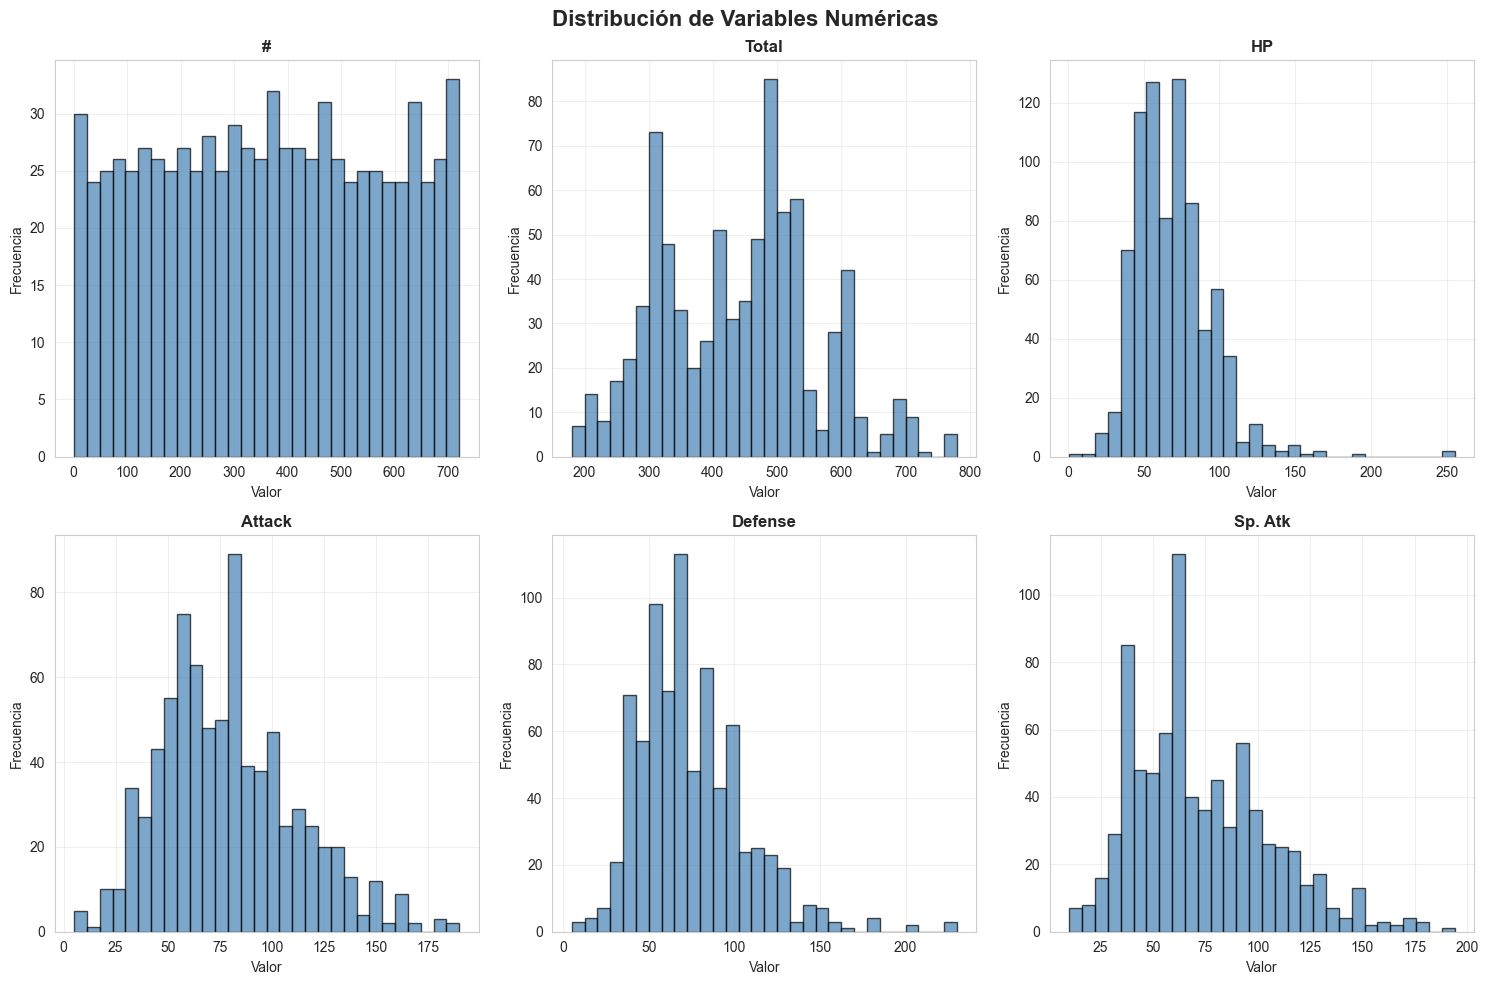

In [10]:
# Histogramas de variables numéricas
numeric_cols = df.select_dtypes(include=['number']).columns
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16, fontweight='bold')
axes = axes.ravel()

for idx, col in enumerate(numeric_cols[:6]):
    axes[idx].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/01_histogramas_variables.png', dpi=300, bbox_inches='tight')
plt.show()

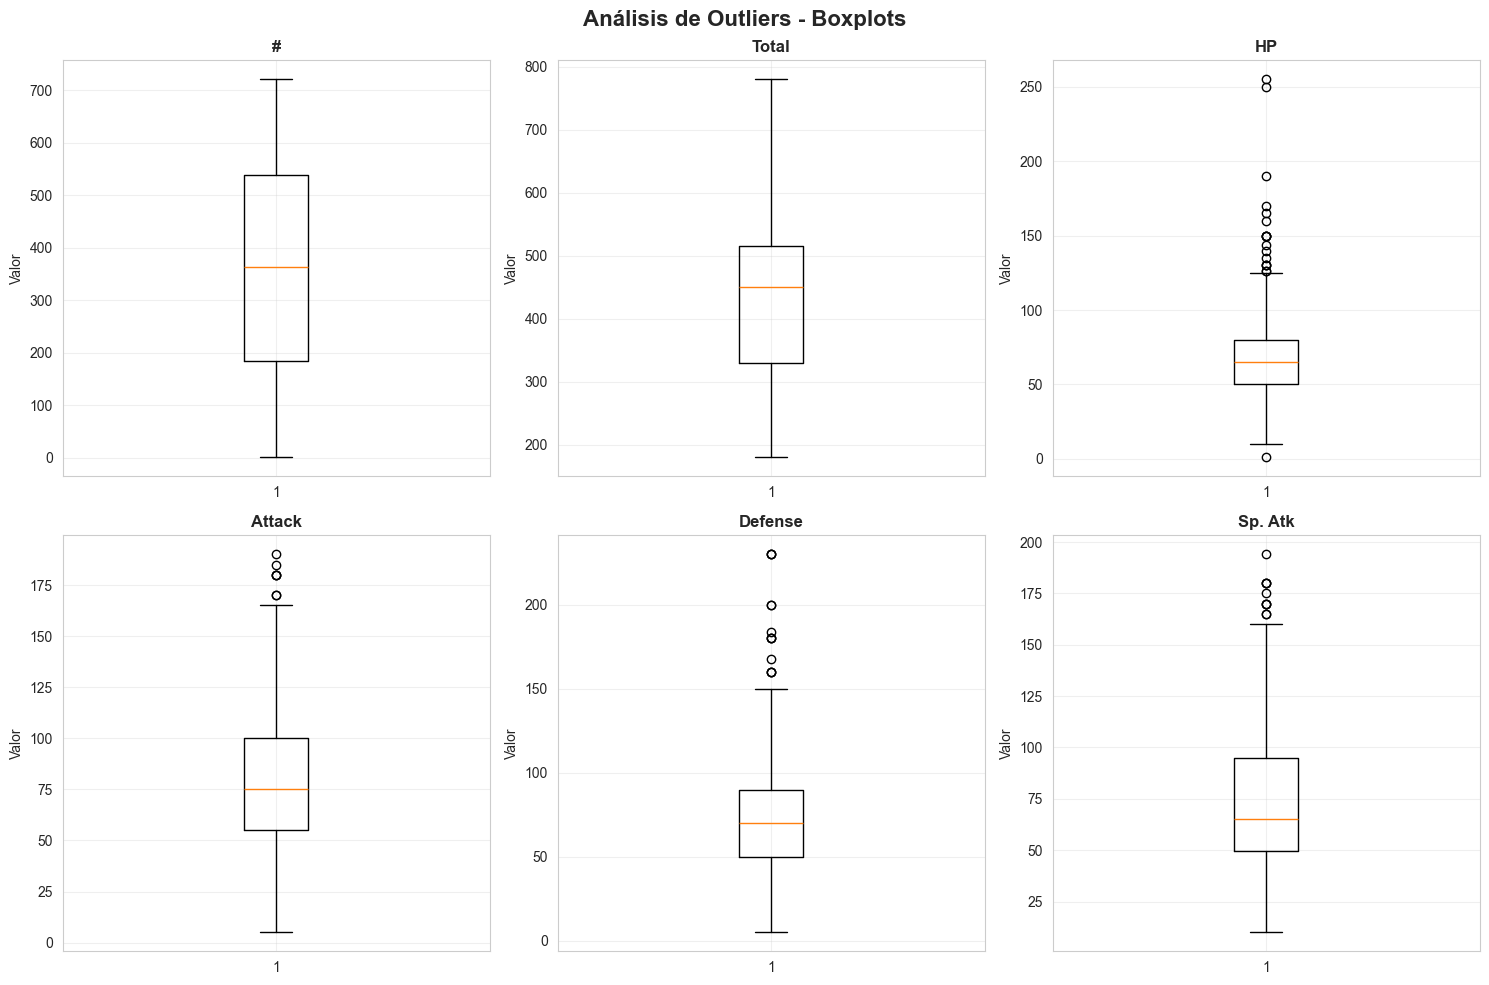

In [11]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Análisis de Outliers - Boxplots', fontsize=16, fontweight='bold')
axes = axes.ravel()

for idx, col in enumerate(numeric_cols[:6]):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_ylabel('Valor')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/02_boxplots_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\diego\AppData\Local\Temp\ipykernel_24688\2833307396.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


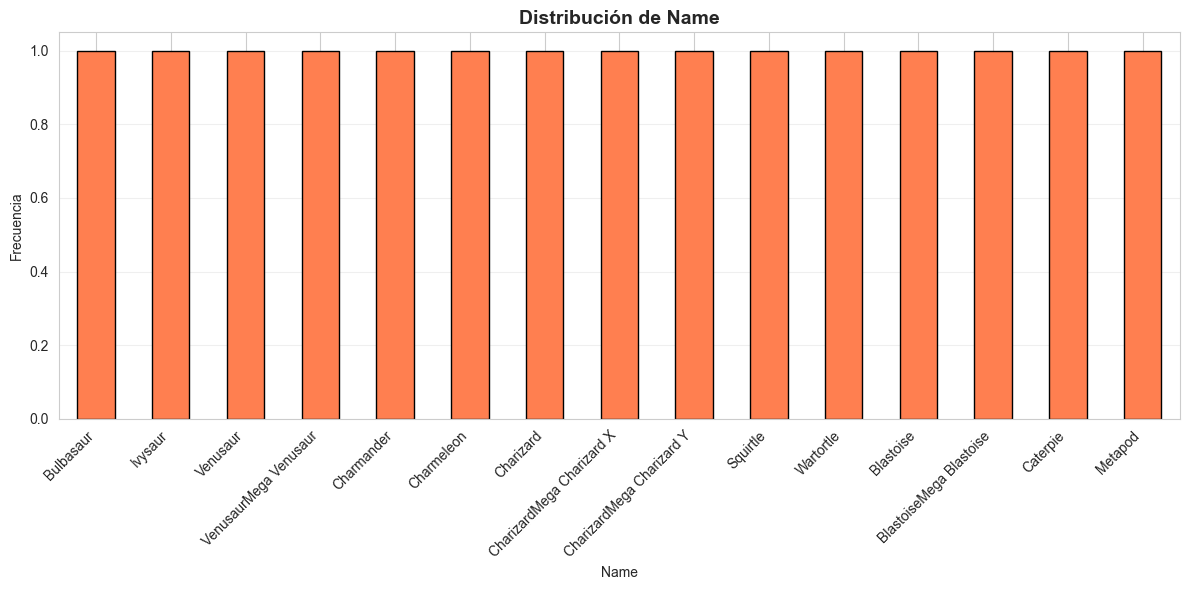

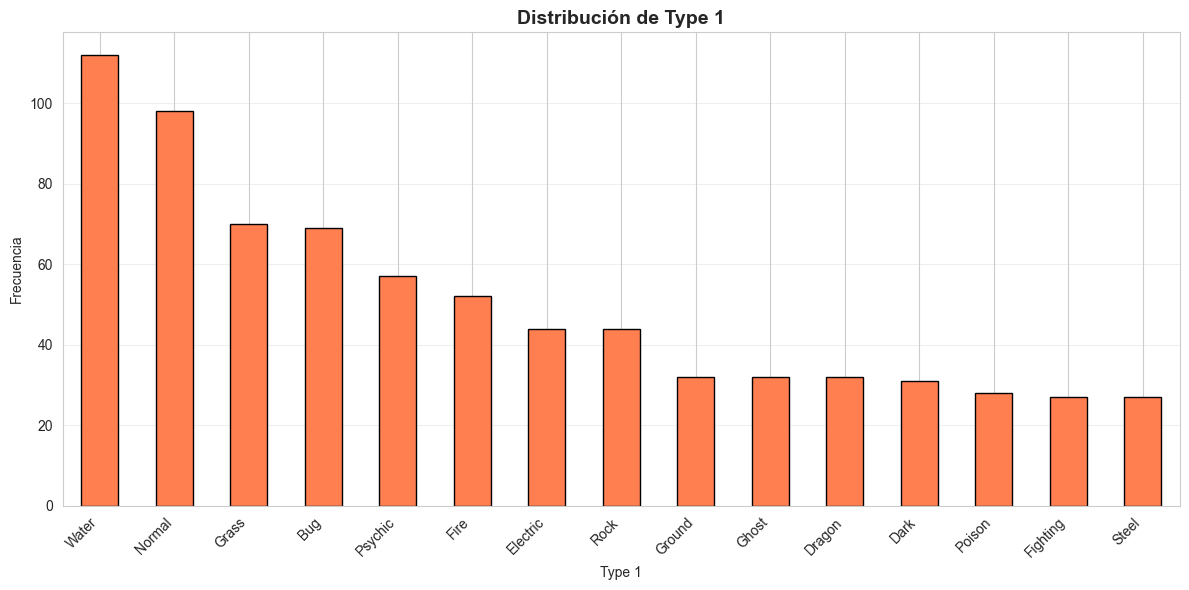

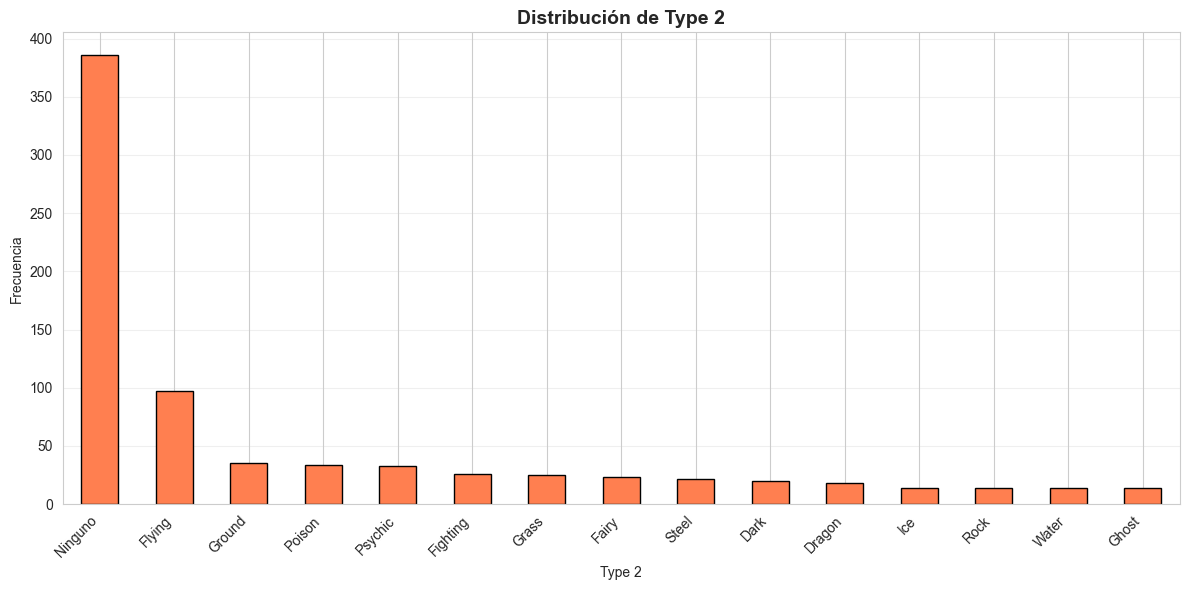

In [12]:
# Gráficos de barras para variables categóricas
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols[:4]:
    fig, ax = plt.subplots(figsize=(12, 6))
    top_values = df[col].value_counts().head(15)
    top_values.plot(kind='bar', color='coral', edgecolor='black', ax=ax)
    ax.set_title(f'Distribución de {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    safe_col_name = col.replace(' ', '_').replace('.', '')
    plt.savefig(f'outputs/03_barplot_{safe_col_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

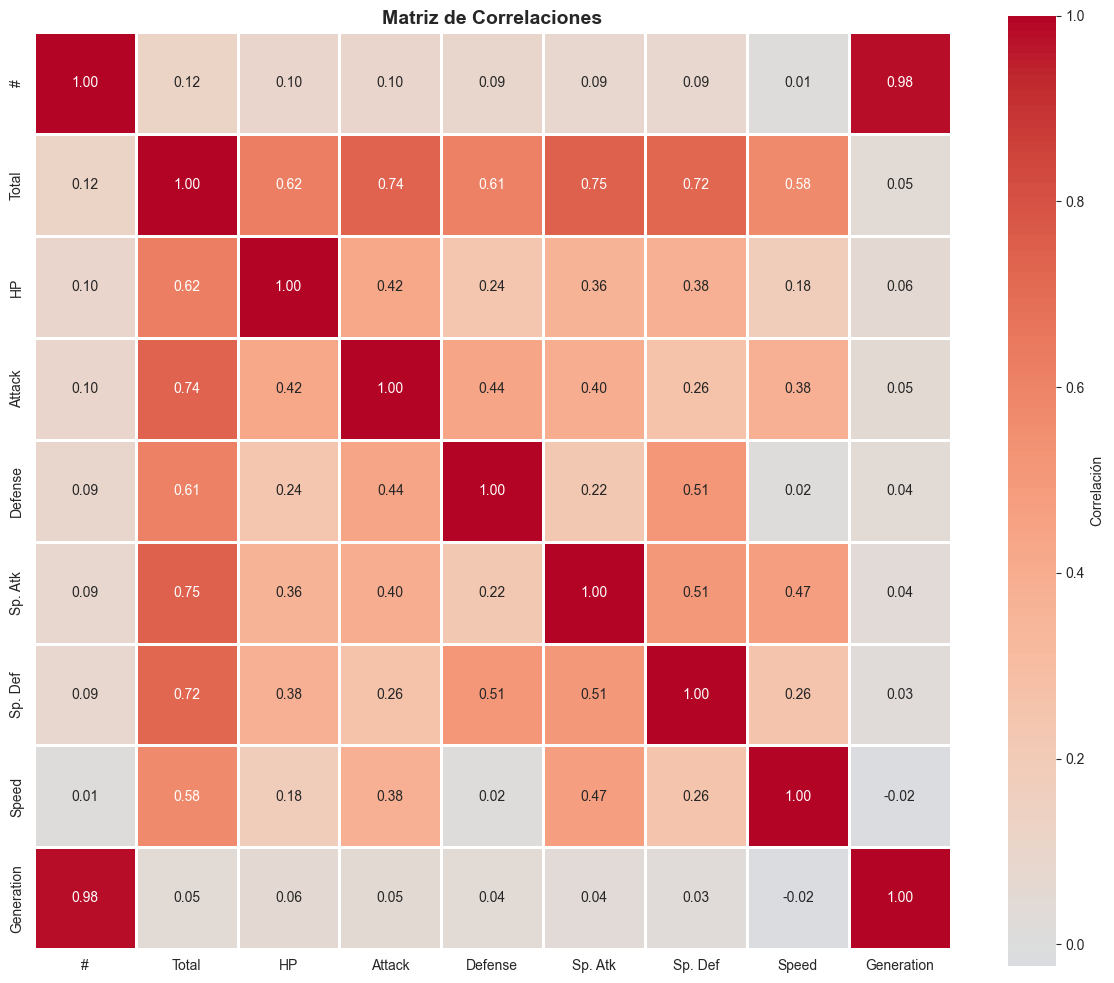

In [13]:
# Matriz de correlaciones con heatmap
fig, ax = plt.subplots(figsize=(12, 10))
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={'label': 'Correlación'},
            ax=ax)
ax.set_title('Matriz de Correlaciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/04_heatmap_correlaciones.png', dpi=300, bbox_inches='tight')
plt.show()

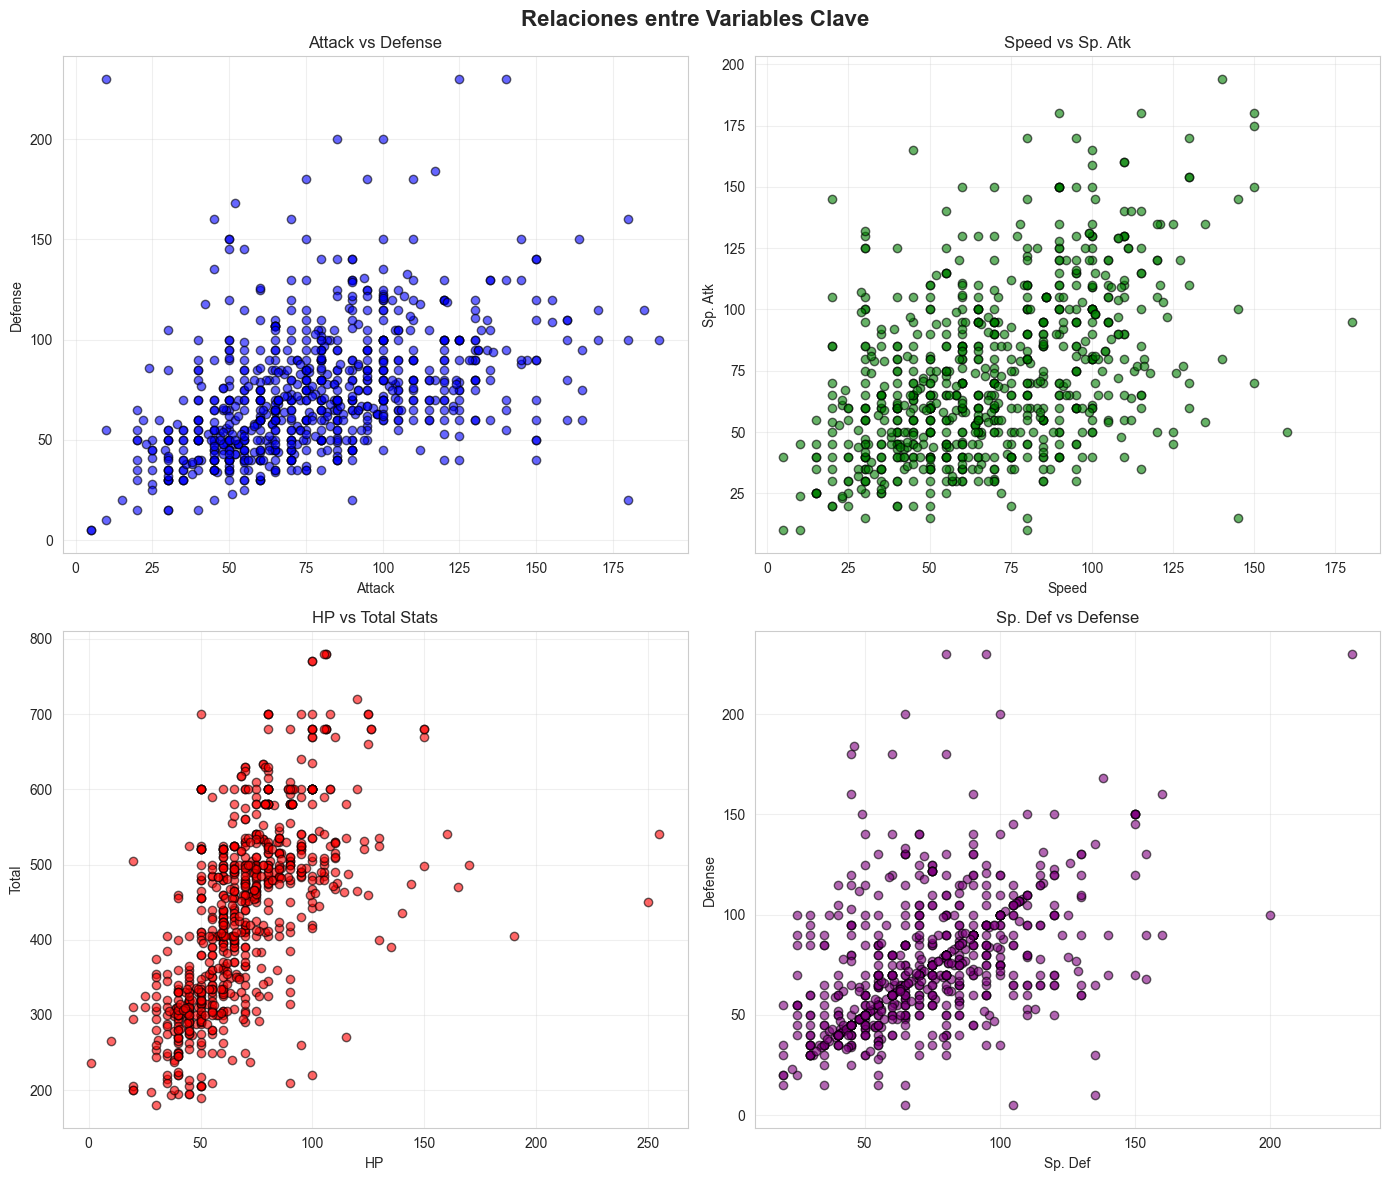

In [14]:
# Scatter plots de variables correlacionadas
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Relaciones entre Variables Clave', fontsize=16, fontweight='bold')

# Attack vs Defense
if 'Attack' in df.columns and 'Defense' in df.columns:
    axes[0, 0].scatter(df['Attack'], df['Defense'], alpha=0.6, color='blue', edgecolor='black')
    axes[0, 0].set_xlabel('Attack')
    axes[0, 0].set_ylabel('Defense')
    axes[0, 0].set_title('Attack vs Defense')
    axes[0, 0].grid(True, alpha=0.3)

# Speed vs Special Attack
if 'Speed' in df.columns and 'Sp. Atk' in df.columns:
    axes[0, 1].scatter(df['Speed'], df['Sp. Atk'], alpha=0.6, color='green', edgecolor='black')
    axes[0, 1].set_xlabel('Speed')
    axes[0, 1].set_ylabel('Sp. Atk')
    axes[0, 1].set_title('Speed vs Sp. Atk')
    axes[0, 1].grid(True, alpha=0.3)

# HP vs Total
if 'HP' in df.columns and 'Total' in df.columns:
    axes[1, 0].scatter(df['HP'], df['Total'], alpha=0.6, color='red', edgecolor='black')
    axes[1, 0].set_xlabel('HP')
    axes[1, 0].set_ylabel('Total')
    axes[1, 0].set_title('HP vs Total Stats')
    axes[1, 0].grid(True, alpha=0.3)

# Sp. Def vs Defense
if 'Sp. Def' in df.columns and 'Defense' in df.columns:
    axes[1, 1].scatter(df['Sp. Def'], df['Defense'], alpha=0.6, color='purple', edgecolor='black')
    axes[1, 1].set_xlabel('Sp. Def')
    axes[1, 1].set_ylabel('Defense')
    axes[1, 1].set_title('Sp. Def vs Defense')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/05_scatterplots_relaciones.png', dpi=300, bbox_inches='tight')
plt.show()

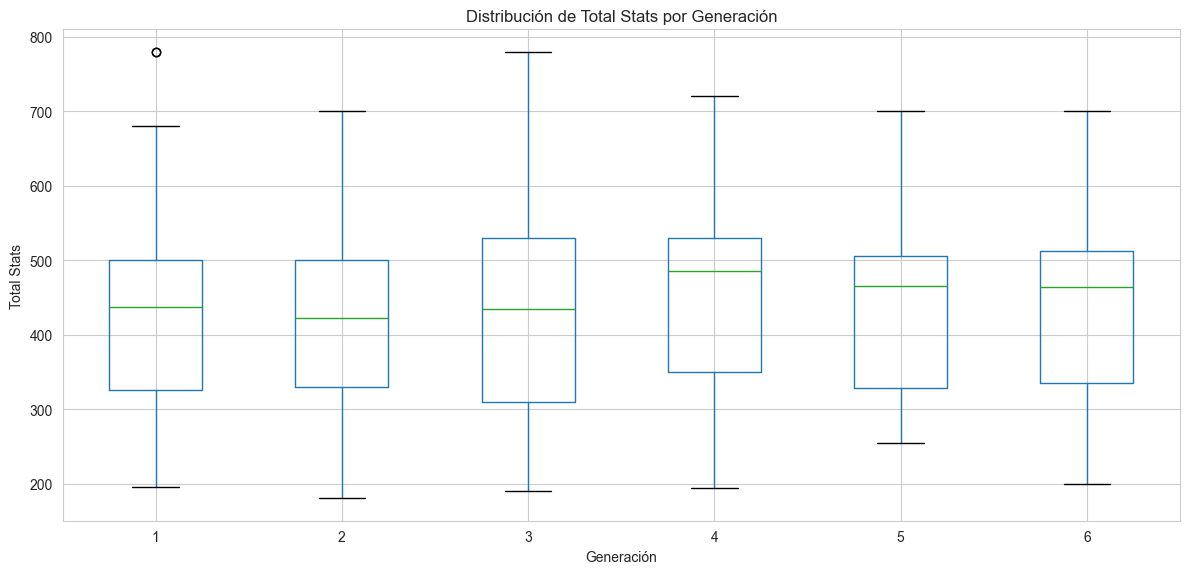

In [15]:
# Distribución de Total Stats por Generación
if 'Total' in df.columns and 'Generation' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    df.boxplot(column='Total', by='Generation', ax=ax)
    ax.set_title('Distribución de Total Stats por Generación')
    ax.set_xlabel('Generación')
    ax.set_ylabel('Total Stats')
    plt.suptitle('')  # Remover título duplicado
    plt.tight_layout()
    plt.savefig('outputs/06_total_stats_por_generacion.png', dpi=300, bbox_inches='tight')
    plt.show()

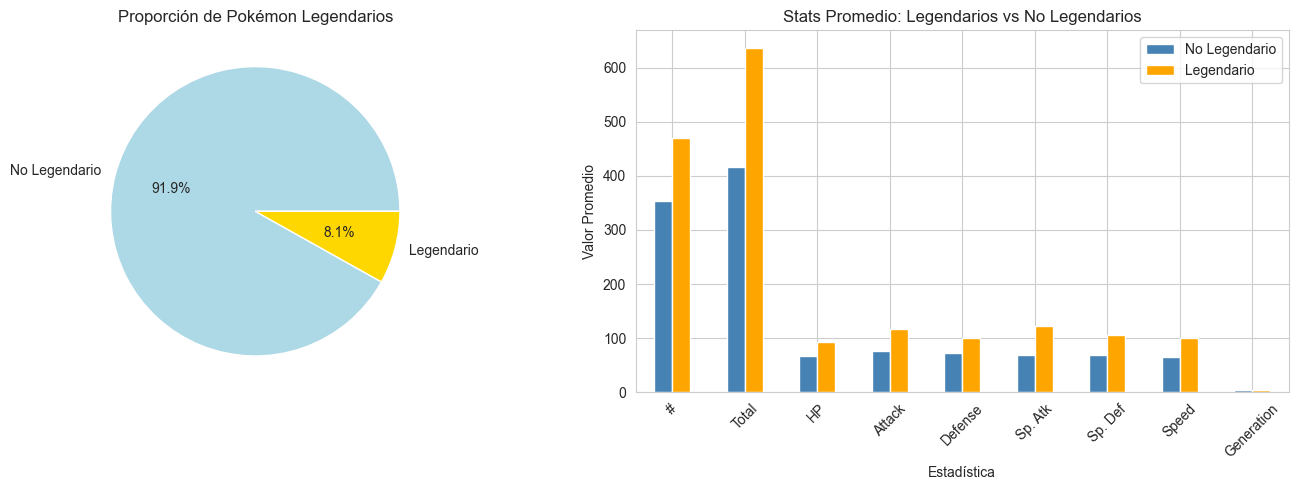

In [16]:
# Gráfico de composición: Leyendarios vs No Leyendarios
if 'Legendary' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pie chart
    legendary_counts = df['Legendary'].value_counts()
    axes[0].pie(legendary_counts.values, labels=['No Legendario', 'Legendario'], 
                autopct='%1.1f%%', colors=['lightblue', 'gold'])
    axes[0].set_title('Proporción de Pokémon Legendarios')
    
    # Estadísticas por tipo
    stats_by_legendary = df.groupby('Legendary')[numeric_cols].mean()
    stats_by_legendary.T.plot(kind='bar', ax=axes[1], color=['steelblue', 'orange'])
    axes[1].set_title('Stats Promedio: Legendarios vs No Legendarios')
    axes[1].set_xlabel('Estadística')
    axes[1].set_ylabel('Valor Promedio')
    axes[1].legend(['No Legendario', 'Legendario'])
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.savefig('outputs/07_legendarios_comparacion.png', dpi=300, bbox_inches='tight')
    plt.show()